Лабораторна робота № 8

Тема. Структура даних граф. Алгоритми на графах

Мета: засвоїти представлення структури даних граф та основні
алгоритми роботи з ними засобами Python.

Хід роботи:

Завдання для самостійної роботи

– Для варіанту, заданого викладачем, задати і візуалізувати граф за допомогою коду, наведеного у цій роботі.

– Для свого варіанту реалізувати всі алгоритми, згідно з прикладами, наведеними вище.


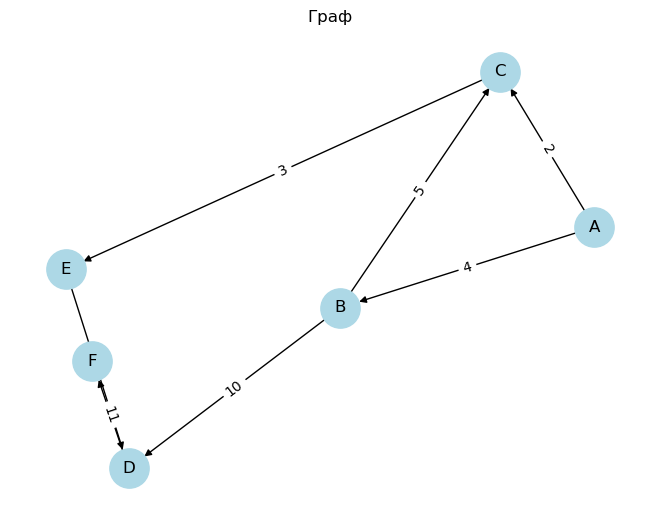

BFS: ['A', 'B', 'C', 'D', 'E', 'F']
DFS: ['A', 'B', 'C', 'E', 'D', 'F']
Dijkstra: {'A': 0, 'B': 4, 'C': 2, 'D': 9, 'E': 5, 'F': 20}
Bellman-Ford: {'A': 0, 'B': 4, 'C': 2, 'D': 9, 'E': 5, 'F': 20}


In [4]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
import heapq


G = nx.DiGraph()

edges = [
    ("A", "B", 4),
    ("A", "C", 2),
    ("B", "C", 5),
    ("B", "D", 10),
    ("C", "E", 3),
    ("E", "D", 4),
    ("D", "F", 11)
]

for u, v, w in edges:
    G.add_edge(u, v, weight=w)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=800)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Граф")
plt.show()


def bfs(graph, start):
    visited = set()
    queue = deque([start])
    order = []

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.add(node)
            order.append(node)
            queue.extend(graph.neighbors(node))

    return order

def dfs(graph, start):
    visited = set()
    stack = [start]
    order = []

    while stack:
        node = stack.pop()
        if node not in visited:
            visited.add(node)
            order.append(node)
            stack.extend(reversed(list(graph.neighbors(node))))

    return order


def dijkstra(graph, start):
    distances = {node: float("inf") for node in graph.nodes()}
    distances[start] = 0

    pq = [(0, start)]

    while pq:
        current_dist, node = heapq.heappop(pq)

        if current_dist > distances[node]:
            continue

        for neighbor in graph.neighbors(node):
            weight = graph[node][neighbor]["weight"]
            dist = current_dist + weight

            if dist < distances[neighbor]:
                distances[neighbor] = dist
                heapq.heappush(pq, (dist, neighbor))

    return distances


def bellman_ford(graph, start):
    distances = {node: float("inf") for node in graph.nodes()}
    distances[start] = 0

    edges_list = [(u, v, graph[u][v]["weight"]) for u, v in graph.edges()]

    for _ in range(len(graph.nodes()) - 1):
        for u, v, w in edges_list:
            if distances[u] + w < distances[v]:
                distances[v] = distances[u] + w

    for u, v, w in edges_list:
        if distances[u] + w < distances[v]:
            raise ValueError("Граф містить негативний цикл")

    return distances

print("BFS:", bfs(G, "A"))
print("DFS:", dfs(G, "A"))
print("Dijkstra:", dijkstra(G, "A"))
print("Bellman-Ford:", bellman_ford(G, "A"))

Контрольні питання:

1.Що таке граф у термінах теорії графів? Наведіть приклади реальних ситуацій, де можна застосовувати графи.

Граф - це абстрактний тип даних, який призначений для реалізації концепцій неорієнтованого і орієнтованого графів, які походять з теорії графів. Граф складається з вузлів і вершин. Приклади:

Транспортні мережі (дороги між містами, відстані або час у дорозі → ваги, задача пошуку найкоротшого шляху), Електричні схеми (вузли = вершини, провідники = ребра)

2.Які основні види графів існують? Наведіть відмінності між орієнтованими і неорієнтованими графами.

Орієнтовані, неорієнтовані, зважені, прості графи, мультиграфи, псевдографи, повні графи, двочасткові графи, дерева, ориєнтовані ациклічні графи.

Орієнтовані графи: ребра мають напрям → A → B ≠ B → A.

Неорієнтовані графи: ребра без напрямку → A — B = B — A.

3.Як можна представити граф у пам’яті комп'ютера? Опишіть структури даних, які використовуються для зберігання графів.

Матриця суміжності - це квадратна матриця розміром N × N, де N — кількість вершин.

Список суміжності - для кожної вершини зберігається список вершин, з якими вона з’єднана.

Список ребер - граф зберігається як список пар.

Матриця інцидентності - матриця розміром V × E: рядки — вершини, стовпці — ребра.

4.Як працює алгоритм пошуку в ширину (BFS) на графах? Наведіть приклади ситуацій, де застосовується цей алгоритм.

Алгоритм використовує чергу (queue), щоб забезпечити обхід у ширину.

Кроки роботи BFS:

-Покласти початкову вершину у чергу.

-Помітити її як відвідану.

-Поки черга не порожня:

 --Взяти вершину з початку черги.

 --Переглянути всіх її сусідів.

 --Якщо сусід ще не відвіданий:

  ---позначити як відвіданий,

  ---додати в чергу.

-Повторювати, поки всі досяжні вершини не буде переглянуто.

Приклади ситуацій, де застосовується цей алгоритм: пошук найкоротшого шляху в незважених графах, пошук шляхів у AI та іграх, перевірка біпартитності графа.

5.Що таке алгоритм пошуку в глибину (DFS) на графах? Як він відрізняється від BFS? Дайте приклади задач, де використовується DFS.

Алгоритм пошуку в глибину (DFS) - це метод обходу графа, який йде якнайдалі в глибину, доки можливо, а потім повертається назад. DFS працює за принципом стека (або через рекурсію).

Де застосовується DFS: пошук шляхів у лабіринтах, перевірка наявності циклів у графах, топологічне сортування, обхід дерев.

DFS — це обхід графа в глибину. BFS же краще працює там, де важливі найкоротші шляхи.

6.Опишіть алгоритм Дейкстри для пошуку найкоротшого шляху в графі. Які умови повинні виконуватися для успішної роботи цього алгоритму?

Алгоритм Дейкстри - це алгоритм пошуку найкоротших шляхів від однієї стартової вершини до всіх інших у зваженому графі без від’ємних ваг ребер.

Кроки алгоритму:

-Ініціалізація

-Пошук найближчої невідвіданої вершини

-Оновлення сусідів обраної вершини

-Позначення вершини як відвіданої

-Повторювати, поки всі вершини не оброблено.